Dataset Loaded
(43739, 16)
✅ Missing Values Handled
delivery_status
1    22392
0    21347
Name: count, dtype: int64


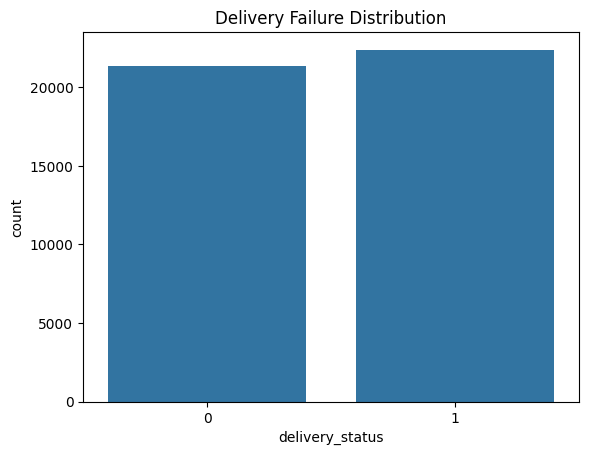

Model Training Completed

Accuracy:
0.8254458161865569

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.89      0.83      4256
           1       0.88      0.76      0.82      4492

    accuracy                           0.83      8748
   macro avg       0.83      0.83      0.83      8748
weighted avg       0.83      0.83      0.82      8748



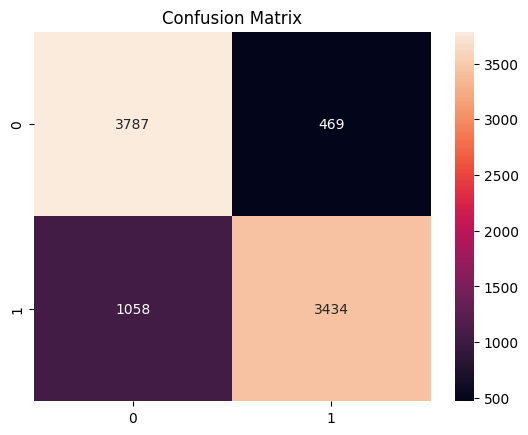


Top Features:

           Feature  Importance
8          Weather    0.123869
0        Agent_Age    0.122053
1     Agent_Rating    0.108441
12        Category    0.093875
15     distance_km    0.091876
6       Order_Time    0.079459
7      Pickup_Time    0.076965
9          Traffic    0.056046
5   Drop_Longitude    0.046664
4    Drop_Latitude    0.046097

Model Saved Successfully

🚚 PROJECT EXECUTED SUCCESSFULLY


In [1]:
# ==================================================
# 🚚 LAST MILE DELIVERY FAILURE PREDICTION
# FAST EXECUTION VERSION
# ==================================================

# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')


# =========================
# LOAD DATASET
# =========================

df = pd.read_csv("../data/amazon_delivery.csv")

print("Dataset Loaded")
print(df.shape)

df.head()


# =========================
# HANDLE MISSING VALUES
# =========================

df = df.ffill()

print("✅ Missing Values Handled")


# =========================
# CREATE TARGET VARIABLE
# =========================

df['delivery_status'] = np.where(
    df['Delivery_Time'] > 120,
    1,
    0
)

print(df['delivery_status'].value_counts())


# =========================
# QUICK EDA
# =========================

sns.countplot(
    x='delivery_status',
    data=df
)

plt.title("Delivery Failure Distribution")

plt.show()


# =========================
# FEATURE ENGINEERING
# =========================

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df['day_of_week'] = df['Order_Date'].dt.dayofweek

df['is_weekend'] = np.where(
    df['day_of_week'] >= 5,
    1,
    0
)


# =========================
# DISTANCE FEATURE
# =========================

def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)

    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))


df['distance_km'] = haversine(
    df['Store_Latitude'],
    df['Store_Longitude'],
    df['Drop_Latitude'],
    df['Drop_Longitude']
)


# =========================
# DROP UNUSED COLUMNS
# =========================

drop_cols = [
    'Order_ID',
    'Order_Date',
    'Delivery_Time'
]

for col in drop_cols:

    if col in df.columns:

        df.drop(col, axis=1, inplace=True)


# =========================
# ENCODE CATEGORICAL DATA
# =========================

le = LabelEncoder()

categorical_cols = df.select_dtypes(
    include='object'
).columns

for col in categorical_cols:

    df[col] = le.fit_transform(
        df[col].astype(str)
    )


# =========================
# SPLIT DATA
# =========================

X = df.drop(
    'delivery_status',
    axis=1
)

y = df['delivery_status']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# =========================
# MODEL TRAINING
# =========================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed")


# =========================
# PREDICTIONS
# =========================

y_pred = model.predict(X_test)


# =========================
# EVALUATION
# =========================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:")
print(accuracy)


print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()


# =========================
# FEATURE IMPORTANCE
# =========================

importance_df = pd.DataFrame({

    'Feature': X.columns,
    'Importance': model.feature_importances_

})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Features:\n")

print(
    importance_df.head(10)
)


# =========================
# SAVE MODEL
# =========================

import pickle

pickle.dump(
    model,
    open("../delivery_failure_model.pkl", "wb")
)

print("\nModel Saved Successfully")


# =========================
# COMPLETED
# =========================

print("\n🚚 PROJECT EXECUTED SUCCESSFULLY")